In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../results/figures")

contact_feature_table = pd.read_csv(
    PROCESSED_DATA_DIR / "contact_feature_table.csv"
)

contact_feature_table.head()


,file_name,study,group,subject_id,trial,file_path,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference
0,GaCo01_01.txt,Ga,Control,GaCo01,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,94,98,0.775760,0.808771,0.777711,0.784538,0.070878,0.126962,0.091137,0.161831,4,0.006827,0.070694
1,GaCo02_01.txt,Ga,Control,GaCo02,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,102,108,0.841782,0.891299,0.702500,0.715782,0.053232,0.111449,0.075774,0.155703,6,0.013282,0.079928
2,GaCo02_02.txt,Ga,Control,GaCo02,2,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,114,115,0.940815,0.949068,0.680303,0.674213,0.068307,0.089574,0.100407,0.132857,1,0.006090,0.032450
3,GaCo03_01.txt,Ga,Control,GaCo03,1,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,94,97,0.775760,0.800518,0.857168,0.806341,0.106978,0.120583,0.124804,0.149544,3,0.050827,0.024739
4,GaCo03_02.txt,Ga,Control,GaCo03,2,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,121.1715,109,108,0.899551,0.891299,0.724902,0.716803,0.080154,0.053564,0.110572,0.074727,1,0.008099,0.035845


In [3]:
contact_feature_table.shape
contact_feature_table["group"].value_counts()

group
Parkinson    214
Control       92
Name: count, dtype: int64

In [4]:
features_to_test = [
    "left_contacts_per_sec",
    "right_contacts_per_sec",
    "mean_left_contact_duration",
    "mean_right_contact_duration",
    "cv_left_contact_duration",
    "cv_right_contact_duration",
    "contact_count_difference",
    "mean_contact_duration_difference",
    "cv_contact_duration_difference"
]

## Statistical testing approach

The feature distributions are not assumed to be normally distributed, and several features contain visible outliers. Therefore, a Mann–Whitney U test is used for the first group comparison between Control and Parkinson recordings.

This test checks whether values from one group tend to be higher or lower than values from the other group. It does not prove clinical importance by itself, so effect size is also calculated.

In [5]:
def rank_biserial_effect_size(u_statistic, n_control, n_parkinson):
    """
    Rank-biserial correlation for Mann-Whitney U.
    Values are roughly between -1 and +1.

    Positive value means Parkinson tends to have higher values.
    Negative value means Control tends to have higher values.
    """
    return (2 * u_statistic) / (n_control * n_parkinson) - 1

In [6]:
mannwhitneyu(parkinson_values, control_values)

NameError: name 'parkinson_values' is not defined

In [7]:
stat_results = []

for feature in features_to_test:
    control_values = contact_feature_table[
        contact_feature_table["group"] == "Control"
    ][feature].dropna()
    
    parkinson_values = contact_feature_table[
        contact_feature_table["group"] == "Parkinson"
    ][feature].dropna()
    
    u_stat, p_value = mannwhitneyu(
        parkinson_values,
        control_values,
        alternative="two-sided"
    )
    
    effect_size = rank_biserial_effect_size(
        u_stat,
        n_control=len(control_values),
        n_parkinson=len(parkinson_values)
    )
    
    stat_results.append({
        "feature": feature,
        "control_median": control_values.median(),
        "parkinson_median": parkinson_values.median(),
        "median_difference_parkinson_minus_control": (
            parkinson_values.median() - control_values.median()
        ),
        "u_statistic": u_stat,
        "p_value": p_value,
        "rank_biserial_effect_size": effect_size,
        "n_control": len(control_values),
        "n_parkinson": len(parkinson_values)
    })

stat_results_table = pd.DataFrame(stat_results)

stat_results_table = stat_results_table.sort_values(
    "p_value"
)

stat_results_table

,feature,control_median,parkinson_median,median_difference_parkinson_minus_control,u_statistic,p_value,rank_biserial_effect_size,n_control,n_parkinson
7,mean_contact_duration_difference,0.008875,0.021305,0.012431,13747.5,3.809759e-08,0.396536,92,214
3,mean_right_contact_duration,0.682939,0.714899,0.031960,11638.5,1.147788e-02,0.182294,92,214
2,mean_left_contact_duration,0.687836,0.712676,0.024840,11290.5,4.160398e-02,0.146942,92,214
4,cv_left_contact_duration,0.109551,0.128962,0.019411,11159.5,6.390003e-02,0.133635,92,214
5,cv_right_contact_duration,0.118838,0.125734,0.006896,11084.5,8.060277e-02,0.126016,92,214
8,cv_contact_duration_difference,0.034473,0.038509,0.004036,10566.5,3.090008e-01,0.073395,92,214
6,contact_count_difference,1.000000,1.000000,0.000000,10329.0,4.753892e-01,0.049269,92,214
1,right_contacts_per_sec,0.916057,0.907804,-0.008253,9725.0,8.673760e-01,-0.012089,92,214
0,left_contacts_per_sec,0.914830,0.907349,-0.007481,9811.0,9.634696e-01,-0.003352,92,214


In [8]:
def benjamini_hochberg_correction(p_values):
    p_values = np.array(p_values)
    n = len(p_values)
    
    sorted_indices = np.argsort(p_values)
    sorted_p_values = p_values[sorted_indices]
    
    corrected = np.empty(n)
    
    for rank, p_value in enumerate(sorted_p_values, start=1):
        corrected[rank - 1] = p_value * n / rank
    
    corrected = np.minimum.accumulate(corrected[::-1])[::-1]
    corrected = np.minimum(corrected, 1.0)
    
    corrected_p_values = np.empty(n)
    corrected_p_values[sorted_indices] = corrected
    
    return corrected_p_values

In [9]:
stat_results_table["p_value_corrected"] = benjamini_hochberg_correction(
    stat_results_table["p_value"].values
)

stat_results_table = stat_results_table.sort_values(
    "p_value_corrected"
)

stat_results_table

,feature,control_median,parkinson_median,median_difference_parkinson_minus_control,u_statistic,p_value,rank_biserial_effect_size,n_control,n_parkinson,p_value_corrected
7,mean_contact_duration_difference,0.008875,0.021305,0.012431,13747.5,3.809759e-08,0.396536,92,214,3.428784e-07
3,mean_right_contact_duration,0.682939,0.714899,0.031960,11638.5,1.147788e-02,0.182294,92,214,5.165044e-02
2,mean_left_contact_duration,0.687836,0.712676,0.024840,11290.5,4.160398e-02,0.146942,92,214,1.248119e-01
4,cv_left_contact_duration,0.109551,0.128962,0.019411,11159.5,6.390003e-02,0.133635,92,214,1.437751e-01
5,cv_right_contact_duration,0.118838,0.125734,0.006896,11084.5,8.060277e-02,0.126016,92,214,1.450850e-01
8,cv_contact_duration_difference,0.034473,0.038509,0.004036,10566.5,3.090008e-01,0.073395,92,214,4.635012e-01
6,contact_count_difference,1.000000,1.000000,0.000000,10329.0,4.753892e-01,0.049269,92,214,6.112146e-01
1,right_contacts_per_sec,0.916057,0.907804,-0.008253,9725.0,8.673760e-01,-0.012089,92,214,9.634696e-01
0,left_contacts_per_sec,0.914830,0.907349,-0.007481,9811.0,9.634696e-01,-0.003352,92,214,9.634696e-01


In [10]:
def interpret_effect_size(value):
    abs_value = abs(value)
    
    if abs_value < 0.1:
        return "very small"
    elif abs_value < 0.3:
        return "small"
    elif abs_value < 0.5:
        return "medium"
    else:
        return "large"

In [11]:
stat_results_table["effect_size_interpretation"] = stat_results_table[
    "rank_biserial_effect_size"
].apply(interpret_effect_size)

stat_results_table

,feature,control_median,parkinson_median,median_difference_parkinson_minus_control,u_statistic,p_value,rank_biserial_effect_size,n_control,n_parkinson,p_value_corrected,effect_size_interpretation
7,mean_contact_duration_difference,0.008875,0.021305,0.012431,13747.5,3.809759e-08,0.396536,92,214,3.428784e-07,medium
3,mean_right_contact_duration,0.682939,0.714899,0.031960,11638.5,1.147788e-02,0.182294,92,214,5.165044e-02,small
2,mean_left_contact_duration,0.687836,0.712676,0.024840,11290.5,4.160398e-02,0.146942,92,214,1.248119e-01,small
4,cv_left_contact_duration,0.109551,0.128962,0.019411,11159.5,6.390003e-02,0.133635,92,214,1.437751e-01,small
5,cv_right_contact_duration,0.118838,0.125734,0.006896,11084.5,8.060277e-02,0.126016,92,214,1.450850e-01,small
8,cv_contact_duration_difference,0.034473,0.038509,0.004036,10566.5,3.090008e-01,0.073395,92,214,4.635012e-01,very small
6,contact_count_difference,1.000000,1.000000,0.000000,10329.0,4.753892e-01,0.049269,92,214,6.112146e-01,very small
1,right_contacts_per_sec,0.916057,0.907804,-0.008253,9725.0,8.673760e-01,-0.012089,92,214,9.634696e-01,very small
0,left_contacts_per_sec,0.914830,0.907349,-0.007481,9811.0,9.634696e-01,-0.003352,92,214,9.634696e-01,very small


In [13]:
stat_results_table.to_csv(
    PROCESSED_DATA_DIR / "statistical_feature_comparison.csv",
    index=False
)

In [14]:
display_cols = [
    "feature",
    "control_median",
    "parkinson_median",
    "median_difference_parkinson_minus_control",
    "p_value",
    "p_value_corrected",
    "rank_biserial_effect_size",
    "effect_size_interpretation"
]

stat_results_table[display_cols]

,feature,control_median,parkinson_median,median_difference_parkinson_minus_control,p_value,p_value_corrected,rank_biserial_effect_size,effect_size_interpretation
7,mean_contact_duration_difference,0.008875,0.021305,0.012431,3.809759e-08,3.428784e-07,0.396536,medium
3,mean_right_contact_duration,0.682939,0.714899,0.031960,1.147788e-02,5.165044e-02,0.182294,small
2,mean_left_contact_duration,0.687836,0.712676,0.024840,4.160398e-02,1.248119e-01,0.146942,small
4,cv_left_contact_duration,0.109551,0.128962,0.019411,6.390003e-02,1.437751e-01,0.133635,small
5,cv_right_contact_duration,0.118838,0.125734,0.006896,8.060277e-02,1.450850e-01,0.126016,small
8,cv_contact_duration_difference,0.034473,0.038509,0.004036,3.090008e-01,4.635012e-01,0.073395,very small
6,contact_count_difference,1.000000,1.000000,0.000000,4.753892e-01,6.112146e-01,0.049269,very small
1,right_contacts_per_sec,0.916057,0.907804,-0.008253,8.673760e-01,9.634696e-01,-0.012089,very small
0,left_contacts_per_sec,0.914830,0.907349,-0.007481,9.634696e-01,9.634696e-01,-0.003352,very small


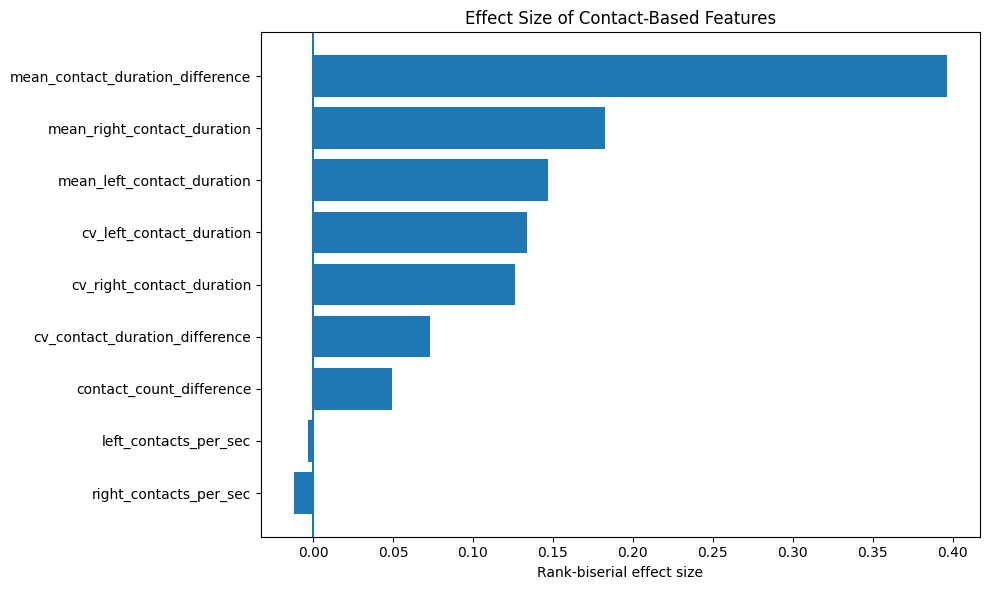

In [15]:
effect_table = stat_results_table.sort_values(
    "rank_biserial_effect_size"
)

plt.figure(figsize=(10, 6))
plt.barh(
    effect_table["feature"],
    effect_table["rank_biserial_effect_size"]
)
plt.axvline(0)
plt.xlabel("Rank-biserial effect size")
plt.title("Effect Size of Contact-Based Features")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "contact_feature_effect_sizes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [16]:
study_stat_results = []

for study in sorted(contact_feature_table["study"].unique()):
    study_df = contact_feature_table[
        contact_feature_table["study"] == study
    ]
    
    for feature in features_to_test:
        control_values = study_df[
            study_df["group"] == "Control"
        ][feature].dropna()
        
        parkinson_values = study_df[
            study_df["group"] == "Parkinson"
        ][feature].dropna()
        
        if len(control_values) == 0 or len(parkinson_values) == 0:
            continue
        
        u_stat, p_value = mannwhitneyu(
            parkinson_values,
            control_values,
            alternative="two-sided"
        )
        
        effect_size = rank_biserial_effect_size(
            u_stat,
            n_control=len(control_values),
            n_parkinson=len(parkinson_values)
        )
        
        study_stat_results.append({
            "study": study,
            "feature": feature,
            "control_median": control_values.median(),
            "parkinson_median": parkinson_values.median(),
            "median_difference_parkinson_minus_control": (
                parkinson_values.median() - control_values.median()
            ),
            "p_value": p_value,
            "rank_biserial_effect_size": effect_size,
            "effect_size_interpretation": interpret_effect_size(effect_size),
            "n_control": len(control_values),
            "n_parkinson": len(parkinson_values)
        })

study_stat_results_table = pd.DataFrame(study_stat_results)

study_stat_results_table.head()

,study,feature,control_median,parkinson_median,median_difference_parkinson_minus_control,p_value,rank_biserial_effect_size,effect_size_interpretation,n_control,n_parkinson
0,Ga,left_contacts_per_sec,0.911931,0.891299,-0.020632,0.679161,-0.048070,very small,38,75
1,Ga,right_contacts_per_sec,0.920183,0.883046,-0.037137,0.543136,-0.070526,very small,38,75
2,Ga,mean_left_contact_duration,0.681066,0.741280,0.060214,0.013267,0.286316,small,38,75
3,Ga,mean_right_contact_duration,0.677908,0.750034,0.072126,0.014684,0.282105,small,38,75
4,Ga,cv_left_contact_duration,0.114367,0.125965,0.011598,0.815001,-0.027368,very small,38,75


In [17]:
direction_table = study_stat_results_table.copy()

direction_table["direction"] = np.where(
    direction_table["rank_biserial_effect_size"] > 0,
    "Parkinson higher",
    "Control higher"
)

direction_summary = (
    direction_table
    .groupby(["feature", "direction"])
    .size()
    .reset_index(name="count")
)

direction_summary

,feature,direction,count
0,contact_count_difference,Parkinson higher,3
1,cv_contact_duration_difference,Control higher,2
2,cv_contact_duration_difference,Parkinson higher,1
3,cv_left_contact_duration,Control higher,1
4,cv_left_contact_duration,Parkinson higher,2
5,cv_right_contact_duration,Control higher,1
6,cv_right_contact_duration,Parkinson higher,2
7,left_contacts_per_sec,Control higher,2
8,left_contacts_per_sec,Parkinson higher,1
9,mean_contact_duration_difference,Parkinson higher,3


In [19]:
direction_pivot = direction_summary.pivot(
    index="feature",
    columns="direction",
    values="count"
).fillna(0)

direction_pivot

direction,Control higher,Parkinson higher
feature,,
contact_count_difference,0.0,3.0
cv_contact_duration_difference,2.0,1.0
cv_left_contact_duration,1.0,2.0
cv_right_contact_duration,1.0,2.0
left_contacts_per_sec,2.0,1.0
mean_contact_duration_difference,0.0,3.0
mean_left_contact_duration,1.0,2.0
mean_right_contact_duration,1.0,2.0
right_contacts_per_sec,2.0,1.0


In [20]:
direction_pivot.to_csv(
    PROCESSED_DATA_DIR / "feature_direction_consistency.csv"
)

## Milestone 5 conclusion

This notebook added statistical comparison and effect-size analysis for the extracted contact-based gait features.

The Mann–Whitney U test was used because the feature distributions contain visible outliers and were not assumed to be normally distributed. Because multiple features were tested, corrected p-values were also calculated.

Effect sizes were included because p-values alone do not show how large or meaningful a difference is. Positive rank-biserial effect sizes indicate that Parkinson recordings tend to have higher values for a feature, while negative values indicate higher values in control recordings.

The most thesis-relevant features are not necessarily the ones with the smallest p-values. Features that show interpretable differences and consistent direction across study groups are more important for the next stage of the project.